# Fresh, Resumable Multimodal Retrieval Benchmark

This notebook trains every consolidated model family again under one split and metric implementation. Historical notebook scores are not used in the final ranking.

Experiments: zero-shot CLIP control, projection tuning, full OpenCLIP fine-tuning, gradual unfreezing, and LoRA OpenCLIP. Progress is saved every 100 batches and after every epoch. Restart and rerun all cells to resume; completed experiments are skipped.

## 1. Environment

Use the repository's `deep_trial` kernel and launch this notebook from its own directory.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from resumable_experiments import SuiteConfig, RetrievalSuite, EXPERIMENTS
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available(): print(torch.cuda.get_device_name(0))

CUDA: True
NVIDIA RTX 6000 Ada Generation


## 2. Configuration

Set `fast_dev_run=True` only for a smoke test and use a different `run_dir`. Keep it `False` for the final benchmark.

In [2]:
cfg=SuiteConfig(data_dir='../data',run_dir='artifacts/fresh_runs',epochs=5,batch_size=128,eval_batch_size=256,checkpoint_every_batches=100,seed=42,fast_dev_run=False)
display(pd.DataFrame(EXPERIMENTS).T)

,strategy,lr,epochs,lora_rank,lora_alpha
clip_zero_shot,zero_shot,0.0,0,NaN,NaN
clip_projection_tuning,projection,0.0001,NaN,NaN,NaN
openclip_full_finetune,full,0.000001,NaN,NaN,NaN
openclip_gradual_unfreeze,gradual,0.000005,NaN,NaN,NaN
openclip_lora,lora,0.0001,NaN,8,16


## 3. Validate data

Suite creation fails early when required tables or images are missing.

In [3]:
suite=RetrievalSuite(cfg)
print(f'Train pairs: {len(suite.train):,}')
print(f'Validation pairs: {len(suite.val):,}')
print('Run directory:',suite.runs)

Train pairs: 40,000
Validation pairs: 5,000
Run directory: /home/student/Deep-Mtech/misc/DL/merged_multimodal_retrieval/artifacts/fresh_runs


## 4. Train or resume every experiment

This is the long-running cell. After an interruption, rerun it. The active experiment resumes from its batch checkpoint and completed experiments print `[skip]`.

In [4]:
comparison=suite.run_all()
display(comparison)

[skip] clip_zero_shot is complete
[skip] clip_projection_tuning is complete
[skip] openclip_full_finetune is complete
[skip] openclip_gradual_unfreeze is complete


/home/student/.conda/envs/deep_trial/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


openclip_lora e1:   0%|          | 0/313 [00:00<?, ?it/s]

openclip_lora e2:   0%|          | 0/313 [00:00<?, ?it/s]

openclip_lora e3:   0%|          | 0/313 [00:00<?, ?it/s]

openclip_lora e4:   0%|          | 0/313 [00:00<?, ?it/s]

openclip_lora e5:   0%|          | 0/313 [00:00<?, ?it/s]

,experiment,strategy,status,best_epoch,trainable_parameters,epoch,train_loss,i2t_R@1,i2t_R@5,i2t_R@10,t2i_R@1,t2i_R@5,t2i_R@10,i2t_score,t2i_score,mean_score
4,openclip_lora,lora,completed,1,1228801,1,0.248644,0.893,0.988,0.999,0.7572,0.9448,0.9766,0.960000,0.892867,0.926433
3,openclip_gradual_unfreeze,gradual,completed,2,149620737,2,0.198485,0.878,0.989,0.997,0.7532,0.9440,0.9780,0.954667,0.891733,0.923200
2,openclip_full_finetune,full,completed,4,149620737,4,0.098227,0.879,0.986,0.996,0.7478,0.9434,0.9742,0.953667,0.888467,0.921067
1,clip_projection_tuning,projection,completed,1,657921,1,0.365832,0.808,0.956,0.981,0.6570,0.8964,0.9452,0.915000,0.832867,0.873933
0,clip_zero_shot,zero_shot,completed,0,0,0,NaN,0.775,0.945,0.977,0.5830,0.8326,0.9040,0.899000,0.773200,0.836100


## 5. Fresh comparison

This table is built exclusively from newly completed experiment records. Mean bidirectional Recall is the primary metric.

In [5]:
results_path=Path(cfg.run_dir)/'fresh_comparison.csv'
fresh=pd.read_csv(results_path).sort_values('mean_score',ascending=False)
cols=['experiment','strategy','best_epoch','i2t_R@1','i2t_R@5','i2t_R@10','t2i_R@1','t2i_R@5','t2i_R@10','mean_score','trainable_parameters']
display(fresh[cols])

,experiment,strategy,best_epoch,i2t_R@1,i2t_R@5,i2t_R@10,t2i_R@1,t2i_R@5,t2i_R@10,mean_score,trainable_parameters
0,openclip_lora,lora,1,0.893,0.988,0.999,0.7572,0.9448,0.9766,0.926433,1228801
1,openclip_gradual_unfreeze,gradual,2,0.878,0.989,0.997,0.7532,0.9440,0.9780,0.923200,149620737
2,openclip_full_finetune,full,4,0.879,0.986,0.996,0.7478,0.9434,0.9742,0.921067,149620737
3,clip_projection_tuning,projection,1,0.808,0.956,0.981,0.6570,0.8964,0.9452,0.873933,657921
4,clip_zero_shot,zero_shot,0,0.775,0.945,0.977,0.5830,0.8326,0.9040,0.836100,0


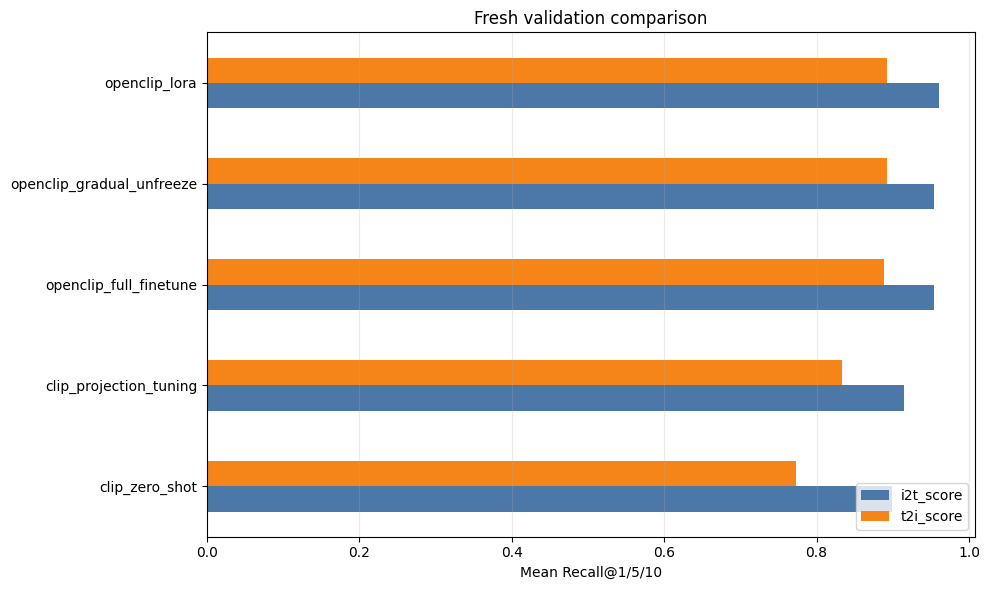

In [6]:
ax=fresh.sort_values('mean_score').plot.barh(x='experiment',y=['i2t_score','t2i_score'],figsize=(10,6),color=['#4C78A8','#F58518'])
ax.set(title='Fresh validation comparison',xlabel='Mean Recall@1/5/10',ylabel=''); ax.grid(axis='x',alpha=.25)
plt.tight_layout(); plt.savefig(Path(cfg.run_dir)/'fresh_comparison.png',dpi=160,bbox_inches='tight'); plt.show()

## 6. Automatic conclusion

The narrative is computed from the fresh result table so it remains correct if a different strategy wins.

In [ ]:
winner=fresh.iloc[0]
print(f'Best fresh model: {winner.experiment}')
print(f'Mean score: {winner.mean_score:.4f}')
print(f'I2T: {winner.i2t_score:.4f} | T2I: {winner.t2i_score:.4f}')
print(f'Best epoch: {int(winner.best_epoch)} | Trainable parameters: {int(winner.trainable_parameters):,}')

Best fresh model: openclip_lora
Mean score: 0.9264
I2T: 0.9600 | T2I: 0.8929
Best epoch: 1 | Trainable parameters: 1,228,801


: 

## Recovery notes

- Kernel/GPU crash: restart and run all cells.
- Failure details: inspect `<experiment>/failure.json`; the last valid checkpoint remains intact.
- Clean rerun: move only the relevant experiment directory.
- Never mix smoke-test and full-run artifacts in the same `run_dir`.